# Deep Learning Recommendation Model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
X = train.drop(columns=["label"]) #input feature DLRM is allowed to see
y = train["label"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
numerical_cols = [f"integer_feature_{i}" for i in range(1, 14)]
categorical_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

num_medians = X_train[numerical_cols].median()

X_train[numerical_cols] = X_train[numerical_cols].fillna(num_medians)
X_val[numerical_cols] = X_val[numerical_cols].fillna(num_medians)

X_train[categorical_cols] = X_train[categorical_cols].fillna(-1)
X_val[categorical_cols] = X_val[categorical_cols].fillna(-1)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #to make feature values into comparable values

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_val[numerical_cols] = scaler.transform(
    X_val[numerical_cols]
)

Representing categorical features with numerical values just like in Vanilla neural network

In [7]:
category_maps = {}
cardinalities = []

for col in categorical_cols:
    categories = X_train[col].unique()

    mapping = {category: idx for idx, category in enumerate(categories)}

    category_maps[col] = mapping

    # +1 for an unknown category
    cardinalities.append(len(mapping) + 1)

    X_train[col] = X_train[col].map(mapping)

    X_val[col] = (
        X_val[col]
        .map(mapping)
        .fillna(len(mapping))   # unknown category index
    )

In [8]:
import torch

#convert data into pytorch tensors
X_train_num = torch.tensor(
    X_train[numerical_cols].values,
    dtype=torch.float32
)

X_val_num = torch.tensor(
    X_val[numerical_cols].values,
    dtype=torch.float32
)

X_train_cat = torch.tensor(
    X_train[categorical_cols].values,
    dtype=torch.long
)

X_val_cat = torch.tensor(
    X_val[categorical_cols].values,
    dtype=torch.long
)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

In [9]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_num,
    X_train_cat,
    y_train
)

val_dataset = TensorDataset(
    X_val_num,
    X_val_cat,
    y_val
)

In [87]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

In [90]:
embedding_dim = 8 #first tried 16

embeddings = nn.ModuleList([
    nn.Embedding(cardinality, embedding_dim)
    for cardinality in cardinalities
])

### Bottom MLP
The 13 numerical features need to become a 8-dimensional dense vector, so they can interact with the 16-dimensional categorical embeddings.

### Top MLP
Pairwise interaction gives 27C2 = 351 values and 8 embedded dense vector from numerical features gives a total of 359 values

In [92]:
bottom_mlp = nn.Sequential(
    nn.Linear(13, 64),
    nn.ReLU(),
    nn.Linear(64, embedding_dim)
)

class DLRM(nn.Module):
    def __init__(self, cardinalities, embedding_dim=8):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embedding_dim)
            for cardinality in cardinalities
        ])

        self.bottom_mlp = nn.Sequential(
            nn.Linear(13, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, embedding_dim)
        )

        self.top_mlp = nn.Sequential(
            nn.Linear(351+embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def interact(self, dense, sparse_embeddings):
        vectors = [dense] + sparse_embeddings

        interactions = []

        for i in range(len(vectors)):
            for j in range(i + 1, len(vectors)):
                interactions.append(
                    (vectors[i] * vectors[j]).sum(dim=1, keepdim=True) #here is where the dot product happens (interactions)
                )

        return torch.cat(interactions, dim=1)

    def forward(self, numerical, categorical):
        # Numerical features -> dense representation
        dense = self.bottom_mlp(numerical)

        # Categorical features -> embeddings
        sparse_embeddings = []

        for i, embedding in enumerate(self.embeddings):
            sparse_embeddings.append(
                embedding(categorical[:, i])
            )

        # Pairwise feature interactions
        interactions = self.interact(
            dense,
            sparse_embeddings
        )

        # Dense vector + interaction values
        x = torch.cat([dense, interactions], dim=1)

        # Final prediction
        return self.top_mlp(x).squeeze(1)


model = DLRM(cardinalities=cardinalities, embedding_dim=embedding_dim)
    

In [93]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)
model = model.to(device)

cuda


In [94]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 3

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()

    total_loss = 0.0

    for numerical, categorical, labels in train_loader:

        numerical = numerical.to(device)
        categorical = categorical.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(numerical, categorical)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    total_loss /= len(train_loader)
    train_losses.append(total_loss)


    model.eval()

    val_loss = 0.0

    with torch.no_grad():
        for numerical, categorical, labels in val_loader:
            numerical = numerical.to(device)
            categorical = categorical.to(device)
            labels = labels.to(device)

            outputs = model(numerical, categorical)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {total_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )
        

Epoch 1/3 | Train Loss: 0.1600 | Val Loss: 0.1371
Epoch 2/3 | Train Loss: 0.1353 | Val Loss: 0.1383
Epoch 3/3 | Train Loss: 0.1231 | Val Loss: 0.1407


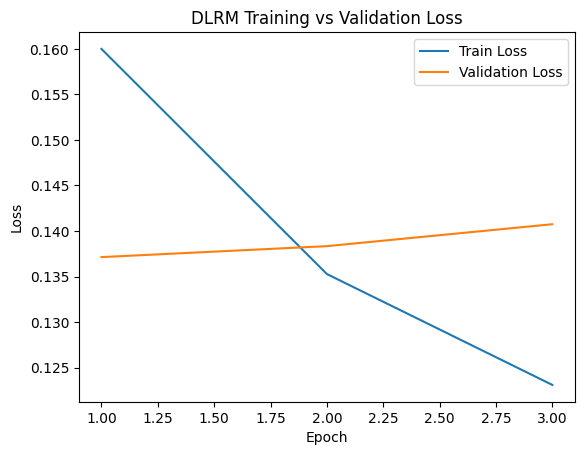

In [95]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DLRM Training vs Validation Loss")
plt.legend()
plt.show()

I first tried without `Dropout` and `weight_decay` in Adam and the model overfit terribly  

Then introduced `Dropout(0.2)` and `weight_decay=1e-4` the model performed slightly better  

Slowly increased both the values till `Dropout(0.4)` and `weight_decay=1e-2` and found above results where overfitting reduced generously due to regularisation

In [96]:
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for numerical, categorical, labels in val_loader:
        numerical = numerical.to(device)
        categorical = categorical.to(device)

        logits = model(numerical, categorical)
        probs = torch.sigmoid(logits)

        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

`Dropout(0.4)` and `weight_decay=1e-2` were too aggressive and model undefit, giving a very poor roc score  
tuned it back to mild regularization

In [98]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    log_loss
)

roc_auc = roc_auc_score(val_labels, val_probs)
pr_auc = average_precision_score(val_labels, val_probs)
logloss = log_loss(val_labels, val_probs)

# Default threshold
threshold = 0.08
val_preds = (np.array(val_probs) >= threshold).astype(int)

f1 = f1_score(val_labels, val_preds)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print(f"F1      : {f1:.4f}")
print(f"Log Loss: {logloss:.4f}")

ROC-AUC : 0.6599
PR-AUC  : 0.0654
F1      : 0.1000
Log Loss: 0.1415


In [ ]:
X_test = test.drop(columns=["label"]).copy()
y_test = test["label"].copy()

X_test[numerical_cols] = X_test[numerical_cols].fillna(num_medians)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

for col in categorical_cols:
    mapping = category_maps[col]

    X_test[col] = (
        X_test[col]
        .map(mapping)
        .fillna(len(mapping))
    )

(10000, 39)
0


In [101]:
X_test_num = torch.tensor(
    X_test[numerical_cols].values,
    dtype=torch.float32
)

X_test_cat = torch.tensor(
    X_test[categorical_cols].values,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

test_dataset = TensorDataset(
    X_test_num,
    X_test_cat,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [102]:
model.eval()

test_probs = []
test_labels = []

with torch.no_grad():
    for numerical, categorical, labels in test_loader:
        numerical = numerical.to(device)
        categorical = categorical.to(device)

        logits = model(numerical, categorical)
        probs = torch.sigmoid(logits)

        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.numpy())

In [103]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score
)

test_roc = roc_auc_score(test_labels, test_probs)
test_pr = average_precision_score(test_labels, test_probs)
test_logloss = log_loss(test_labels, test_probs)

test_preds = (np.array(test_probs) >= 0.5).astype(int)
test_f1 = f1_score(test_labels, test_preds)

print(f"Test ROC-AUC: {test_roc:.4f}")
print(f"Test PR-AUC:  {test_pr:.4f}")
print(f"Test Log Loss: {test_logloss:.4f}")
print(f"Test F1 @ 0.5: {test_f1:.4f}")

Test ROC-AUC: 0.6412
Test PR-AUC:  0.0701
Test Log Loss: 0.1491
Test F1 @ 0.5: 0.0000


Got a ROC of 0.64 which is lower than the vanilla neural network, but this might be happening due to the sparse information provided in dataset as dataset is small and does not have much meaningful interactions to conclude a click  
Also the PR is 0.07 which is better than the vanilla which suggest dlrm is finding the positive class slightly better than the vanilla